In [1]:
pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

In [3]:
pd.__version__

'3.0.5'

In [4]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

In [5]:
df.shape

(10000, 11)

In [8]:
df.head()


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [9]:
columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
]

df = df[columns]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

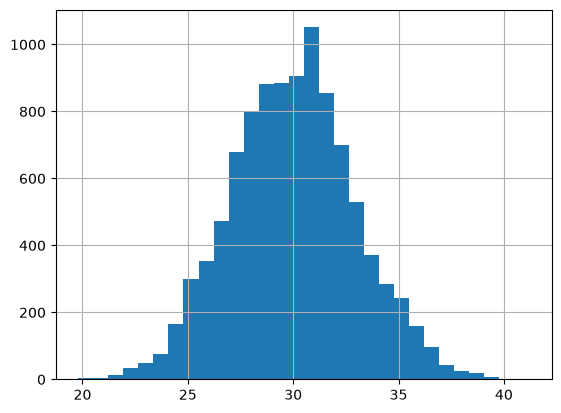

In [10]:
df["fuel_efficiency_mpg"].hist(bins=30)

In [13]:
## Q1 Coulmn with missing value 

In [11]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [12]:
## Q2 : horsepower 

In [14]:
df["horsepower"].median()

np.float64(254.0)

In [16]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))

Train: 6000
Validation: 2000
Test: 2000


In [17]:
## Q3 Prepare target value

In [18]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values

print("Training targets:", y_train.shape)
print("Validation targets:", y_val.shape)

Training targets: (6000,)
Validation targets: (2000,)


In [19]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

X_train_zero = df_train[features].fillna(0).values
X_val_zero = df_val[features].fillna(0).values

print("Training inputs:", X_train_zero.shape)
print("Validation inputs:", X_val_zero.shape)
print("Missing values left in training inputs:", np.isnan(X_train_zero).sum())

Training inputs: (6000, 4)
Validation inputs: (2000, 4)
Missing values left in training inputs: 0


In [20]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

print("Intercept:", w0_zero)
print("Feature weights:", w_zero)

Intercept: -153.8849618823488
Feature weights: [-1.51505520e-03 -4.74024795e-06 -3.95418397e-03  1.02146785e-01]


In [21]:
## Q3, next step: Measure the zero-filled model

In [22]:
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)

rmse_zero = np.sqrt(np.mean((y_val - y_pred_zero) ** 2))

print("First 5 predictions:", y_pred_zero[:5])
print("First 5 actual values:", y_val[:5])
print("Validation RMSE:", round(rmse_zero, 3))

First 5 predictions: [31.64502134 29.86572978 31.58838899 30.02584068 31.006497  ]
First 5 actual values: [30.4 32.8 27.8 28.6 31.1]
Validation RMSE: 2.205


In [23]:
## next step: Calculate the training mean

In [24]:
horsepower_mean = df_train["horsepower"].mean()

print("Training mean horsepower:", horsepower_mean)

Training mean horsepower: 254.46338337605272


In [25]:
X_train_mean = df_train[features].fillna(horsepower_mean).values
X_val_mean = df_val[features].fillna(horsepower_mean).values

print("Training inputs:", X_train_mean.shape)
print("Validation inputs:", X_val_mean.shape)
print("Missing values left:", np.isnan(X_train_mean).sum())

Training inputs: (6000, 4)
Validation inputs: (2000, 4)
Missing values left: 0


In [26]:
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = np.sqrt(np.mean((y_val - y_pred_mean) ** 2))

print("RMSE with zero:", round(rmse_zero, 3))
print("RMSE with mean:", round(rmse_mean, 3))

RMSE with zero: 2.205
RMSE with mean: 2.202


In [27]:
## Q4 Add regularization to the training function

In [28]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    w = np.linalg.solve(XTX, X.T.dot(y))

    return w[0], w[1:]

print("Regularized training function is ready")

Regularized training function is ready


In [29]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r)

    y_pred = w0 + X_val_zero.dot(w)
    score = np.sqrt(np.mean((y_val - y_pred) ** 2))

    print(f"r={r:<6} RMSE={round(score, 4)}")

r=0      RMSE=2.2053
r=0.01   RMSE=2.2058
r=0.1    RMSE=2.2241
r=1      RMSE=2.3492
r=5      RMSE=2.4094
r=10     RMSE=2.4195
r=100    RMSE=2.4292


In [30]:
## Q5 Repeat the split with seeds 0–9

In [31]:
def split_data(seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    train = df.iloc[idx[:n_train]]
    val = df.iloc[idx[n_train:n_train + n_val]]
    test = df.iloc[idx[n_train + n_val:]]

    return train, val, test

train_0, val_0, test_0 = split_data(0)

print(len(train_0), len(val_0), len(test_0))

6000 2000 2000


In [32]:
scores = []

for seed in range(10):
    train, val, test = split_data(seed)

    X_train = train[features].fillna(0).values
    X_val = val[features].fillna(0).values
    y_train_seed = train["fuel_efficiency_mpg"].values
    y_val_seed = val["fuel_efficiency_mpg"].values

    w0, w = train_linear_regression(X_train, y_train_seed)
    y_pred = w0 + X_val.dot(w)

    score = np.sqrt(np.mean((y_val_seed - y_pred) ** 2))
    scores.append(score)

    print(f"Seed {seed}: RMSE = {score:.4f}")

Seed 0: RMSE = 2.2392
Seed 1: RMSE = 2.2021
Seed 2: RMSE = 2.1634
Seed 3: RMSE = 2.2044
Seed 4: RMSE = 2.2019
Seed 5: RMSE = 2.2458
Seed 6: RMSE = 2.2697
Seed 7: RMSE = 2.1908
Seed 8: RMSE = 2.2166
Seed 9: RMSE = 2.2070


In [33]:
std = np.std(scores)

print("Standard deviation:", std)
print("Rounded answer:", round(std, 3))

Standard deviation: 0.02878127407824958
Rounded answer: 0.029


In [34]:
## Q6, next step: Combine training and validation data

In [35]:
df_train_9, df_val_9, df_test_9 = split_data(9)

df_train_full = pd.concat([df_train_9, df_val_9])

print("Combined training rows:", len(df_train_full))
print("Test rows:", len(df_test_9))

Combined training rows: 8000
Test rows: 2000


In [36]:
## next step : prepare the input target 

In [37]:
X_train_full = df_train_full[features].fillna(0).values
X_test = df_test_9[features].fillna(0).values

y_train_full = df_train_full["fuel_efficiency_mpg"].values
y_test = df_test_9["fuel_efficiency_mpg"].values

print("Training inputs:", X_train_full.shape)
print("Test inputs:", X_test.shape)
print("Missing values left:", np.isnan(X_train_full).sum())

Training inputs: (8000, 4)
Test inputs: (2000, 4)
Missing values left: 0


In [38]:
## net step - train and evaluate 

In [39]:
w0_final, w_final = train_linear_regression_reg(
    X_train_full, y_train_full, r=0.001
)

y_pred_test = w0_final + X_test.dot(w_final)
rmse_test = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

print("Test RMSE:", rmse_test)
print("Rounded answer:", round(rmse_test, 3))

Test RMSE: 2.2358277471953802
Rounded answer: 2.236
